# Linear models: scratchlearn vs scikit-learn

A side-by-side check of my `LinearRegression`, `Ridge` and `Lasso` against scikit-learn
on one synthetic regression problem. The point is not to beat scikit-learn (the maths is
identical) but to see the coefficients land in the same place.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
import sklearn.linear_model as sk

from scratchlearn.linear_model import LinearRegression, Ridge, Lasso
from scratchlearn.model_selection import train_test_split

X, y = make_regression(n_samples=200, n_features=10, n_informative=4, noise=8.0,
                       random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
X_train.shape, X_test.shape

((150, 10), (50, 10))

In [2]:
pairs = [
    ("LinearRegression", LinearRegression(), sk.LinearRegression()),
    ("Ridge(alpha=10)", Ridge(alpha=10.0), sk.Ridge(alpha=10.0)),
    ("Lasso(alpha=2)", Lasso(alpha=2.0, max_iter=5000), sk.Lasso(alpha=2.0, max_iter=50000)),
]
print(f"{'model':<20} {'ours R2':>10} {'sklearn R2':>12} {'max |coef diff|':>17}")
for name, ours, theirs in pairs:
    ours.fit(X_train, y_train)
    theirs.fit(X_train, y_train)
    diff = np.abs(ours.coef_ - theirs.coef_).max()
    print(f"{name:<20} {ours.score(X_test, y_test):>10.4f} "
          f"{theirs.score(X_test, y_test):>12.4f} {diff:>17.2e}")

model                   ours R2   sklearn R2   max |coef diff|
LinearRegression         0.9816       0.9816          5.68e-14
Ridge(alpha=10)          0.9724       0.9724          7.11e-15
Lasso(alpha=2)           0.9736       0.9736          3.28e-06


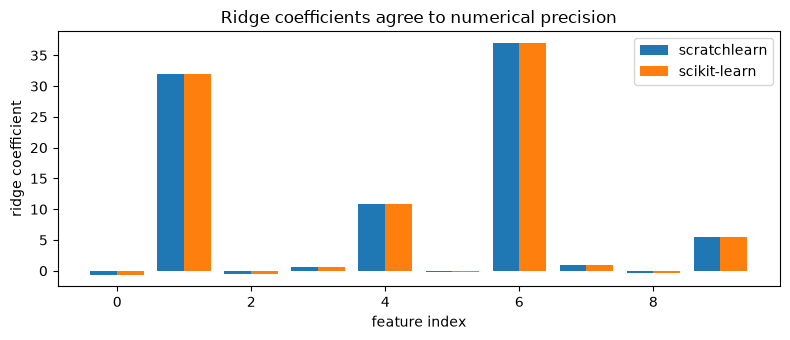

In [ ]:
ours_ridge = pairs[1][1]
theirs_ridge = pairs[1][2]
idx = np.arange(X.shape[1])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(idx - 0.2, ours_ridge.coef_, width=0.4, label="scratchlearn")
ax.bar(idx + 0.2, theirs_ridge.coef_, width=0.4, label="scikit-learn")
ax.set_xlabel("feature index")
ax.set_ylabel("ridge coefficient")
ax.set_title("Ridge regression coefficients comparison")
ax.legend()
plt.tight_layout()

## The lasso path

Sweeping the L1 strength shows that as alpha
grows, coefficients are driven to exactly zero one by one. The noise features first, the
four informative ones last, until nothing is left.

non-zero coefficients at alpha=0.01: 10
non-zero coefficients at alpha=100: 0


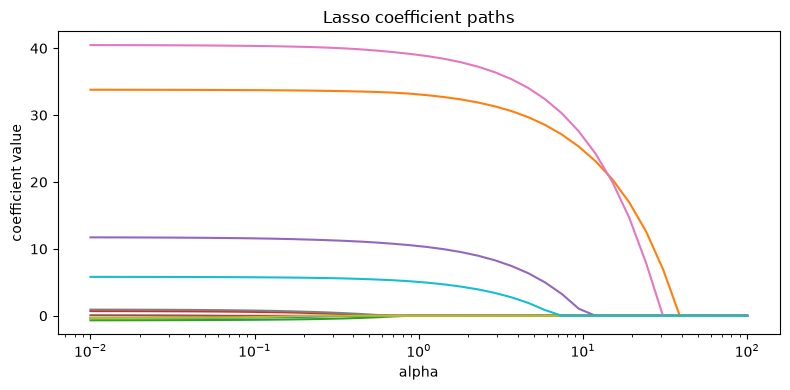

In [4]:
alphas = np.logspace(-2, 2, 40)
path = np.array([Lasso(alpha=a, max_iter=5000).fit(X_train, y_train).coef_ for a in alphas])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, path)
ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("coefficient value")
ax.set_title("Lasso coefficient paths")
plt.tight_layout()

nonzero = (path != 0).sum(axis=1)
print("non-zero coefficients at alpha=0.01:", nonzero[0])
print("non-zero coefficients at alpha=100:", nonzero[-1])